<a href="https://colab.research.google.com/github/hajyhia/Airbnb_Berlin_Price_predic/blob/main/02_Airbnb_Berlin_EDA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install missingno
# !pip install autoviz
# !pip install geopy
# !pip install scipy
# !pandas_profiling
# !pip install statsmodels
# !pip install pyodbc
# !pip install seaborn
# !pip install nltk

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import missingno as msno
sns.set()
plt.style.use('ggplot')
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df_EDA = pd.read_pickle('/content/drive/My Drive/Airbnb/df_EDA.pkl')

In [5]:
df = df_EDA.copy()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23460 entries, 0 to 23535
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Accuracy Rating        18862 non-null  float64
 1   Bathrooms              23431 non-null  float64
 2   Checkin Rating         18844 non-null  float64
 3   Cleanliness Rating     18866 non-null  float64
 4   Communication Rating   18860 non-null  float64
 5   Host Response Rate     12984 non-null  float64
 6   Latitude               23460 non-null  float64
 7   Location Rating        18845 non-null  float64
 8   Longitude              23460 non-null  float64
 9   Overall Rating         18888 non-null  float64
 10  Price                  23460 non-null  float64
 11  Square Feet            425 non-null    float64
 12  Value Rating           18842 non-null  float64
 13  review_date            19352 non-null  object 
 14  Comments               19350 non-null  object 
 15  Host Si

## Defines data columns Lists

In [7]:
numerical_columns = ['Price','Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Guests Included','Min Nights','Reviews']
rating_columns = ['Value Rating','Location Rating', 'Cleanliness Rating','Checkin Rating','Accuracy Rating','Communication Rating','Host Response Rate','Overall Rating']
boolean_columns = ['Is Superhost','Is Exact Location', 'Instant Bookable']
categorical_columns = ['Room Type','Property Type Reduced','Neighborhood Group','Postal Code Reduced','Host Response Time']
date_columns = ['review_date','Host Since']
non_categorical_columns = numerical_columns + rating_columns + boolean_columns

# EDA - Explenatory Data Analysis

In [8]:
df.head(2)

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Latitude,Location Rating,Longitude,Overall Rating,Price,Square Feet,Value Rating,review_date,Comments,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced
0,10.0,1.0,10.0,10.0,10.0,50.0,52.54851,9.0,13.40455,100.0,17.0,NaN,10.0,07-04-18,I really enjoyed staying at Micha and Nadja's ...,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,2,1.0,1.0,1,2,7,Apartment,10
1,9.0,1.0,9.0,9.0,9.0,50.0,52.53500,10.0,13.41758,92.0,90.0,720.0,9.0,06-20-09,"excellent stay, i would highly recommend it. a...",10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,4,1.0,2.0,2,62,144,Apartment,10


## Data Protocol

In [9]:
#Type of data
df.dtypes.to_excel ("df_datatype.xlsx", sheet_name='data_types')

#Maximum points
df[non_categorical_columns].max().to_excel("df_max.xlsx", sheet_name='max')

#Minimum points
df[non_categorical_columns].max().to_excel("df_max.xlsx", sheet_name='min')

#Isnull values
df.isnull().to_excel("df_isnull.xlsx", sheet_name='isnull')

#unique values
df.nunique().to_excel("df_nunique.xlsx", sheet_name='nunique')

# Categorical values
df[categorical_columns].describe().to_excel("df_categorical.xlsx", sheet_name='categorical')

In [10]:
# from autoviz.AutoViz_Class import AutoViz_Class
# %matplotlib inline

# AV = AutoViz_Class()
# AV.AutoViz(df)

**commented out AtuoViz because teh size of the file was too big for github to present**

## Descriptive statistics
   

In [11]:
df.shape

(23460, 33)

In [12]:
df[numerical_columns].describe()

,Price,Accomodates,Bathrooms,Bedrooms,Beds,Guests Included,Min Nights,Reviews
count,23460.000000,23460.000000,23431.000000,23440.000000,23426.000000,23460.000000,23460.000000,23460.000000
mean,60.926726,2.668031,1.095088,1.160154,1.640101,1.344757,6.906053,19.284186
std,49.445524,1.550610,0.341949,0.654637,1.219281,0.851014,24.907073,40.410275
min,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,31.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000
50%,49.000000,2.000000,1.000000,1.000000,1.000000,1.000000,3.000000,5.000000
75%,74.000000,3.000000,1.000000,1.000000,2.000000,1.000000,4.000000,17.000000
max,600.000000,16.000000,8.500000,10.000000,22.000000,16.000000,1000.000000,545.000000


In [13]:
df[rating_columns].describe()

,Value Rating,Location Rating,Cleanliness Rating,Checkin Rating,Accuracy Rating,Communication Rating,Host Response Rate,Overall Rating
count,18842.000000,18845.000000,18866.000000,18844.000000,18862.000000,18860.000000,12984.000000,18888.000000
mean,9.418268,9.550756,9.335047,9.728826,9.680946,9.746819,91.832640,94.570945
std,0.837989,0.747908,1.030239,0.695025,0.733149,0.677487,19.444915,7.569704
min,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000,20.000000
25%,9.000000,9.000000,9.000000,10.000000,10.000000,10.000000,95.000000,92.000000
50%,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,97.000000
75%,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,100.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,100.000000


In [14]:
df[boolean_columns].describe()

,Is Superhost,Is Exact Location,Instant Bookable
count,23460,23460,23460
unique,2,2,2
top,False,True,False
freq,19901,17610,15631


In [15]:
df[categorical_columns].describe()

,Room Type,Property Type Reduced,Neighborhood Group,Postal Code Reduced,Host Response Time
count,23460,23460,23460,23460,12984
unique,3,15,12,8,4
top,Private room,Apartment,Friedrichshain-Kreuzberg,10,within an hour
freq,11658,20914,5720,14613,6780


In [16]:
# df[['Host Since Year', 'Host Since Month', 'Host Since Day']].describe()

Several rows with unusually high values can be identified and may in some cases be dropped at a certain threshold

The description of price shows that 75% of the room only charged within 70€. But we can find the maximized price is extremely large - up to 9000€.

In [17]:
df[['Beds', 'Min Nights', 'Reviews', 'Price']].describe().loc[['max']].T

,max
Beds,22.0
Min Nights,1000.0
Reviews,545.0
Price,600.0


## Target Value

In [18]:
df[['Price']].describe()

,Price
count,23460.000000
mean,60.926726
std,49.445524
min,1.000000
25%,31.000000
50%,49.000000
75%,74.000000
max,600.000000


The description of price shows that 75% of the room only charged within 70€. But we can find the maximized price is extremely large - up to 9000€.

### Distribution of Price

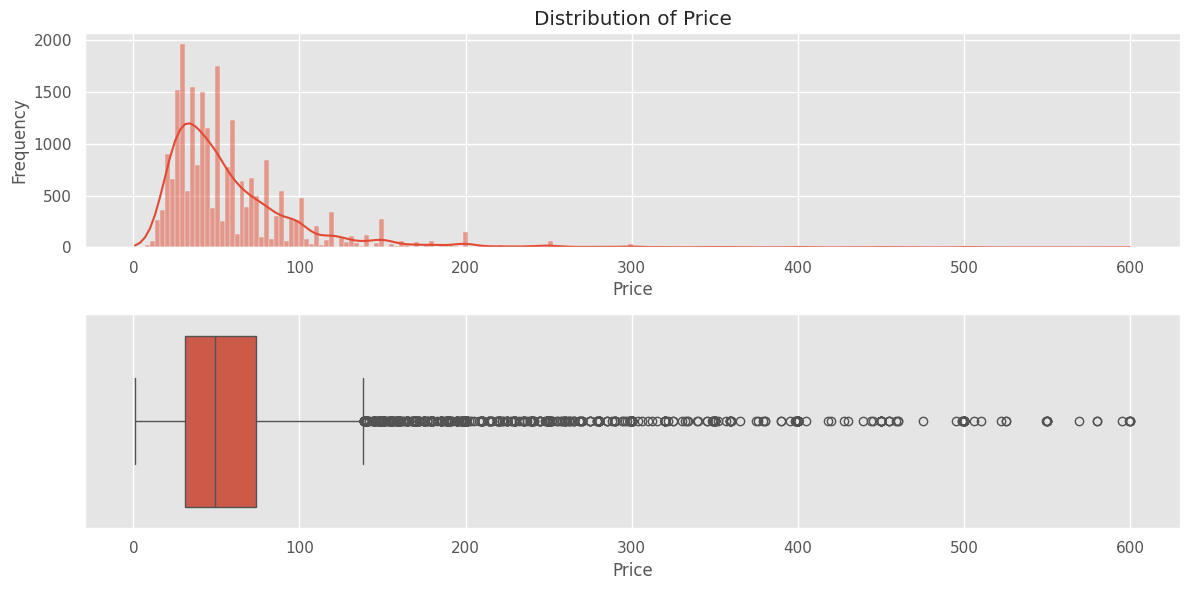

In [19]:
def target_value_distributions(df):
  plt.figure(figsize=(12, 6))
  plt.subplot(2, 1, 1)
  sns.histplot(df['Price'], bins=200, kde=True)
  plt.title("Distribution of Price")
  plt.xlabel("Price")
  plt.ylabel("Frequency")

  plt.subplot(2, 1, 2)
  sns.boxplot(df['Price'], orient='h')
  plt.xlabel("Price")

  plt.tight_layout()
  plt.show()

# Distribution of Price before dropping extream outlier values
target_value_distributions(df)

In [20]:
# df = df[(df['Price'] <= 600) & (df['Price'] > 0)]
df['Price'].describe()

,Price
count,23460.000000
mean,60.926726
std,49.445524
min,1.000000
25%,31.000000
50%,49.000000
75%,74.000000
max,600.000000


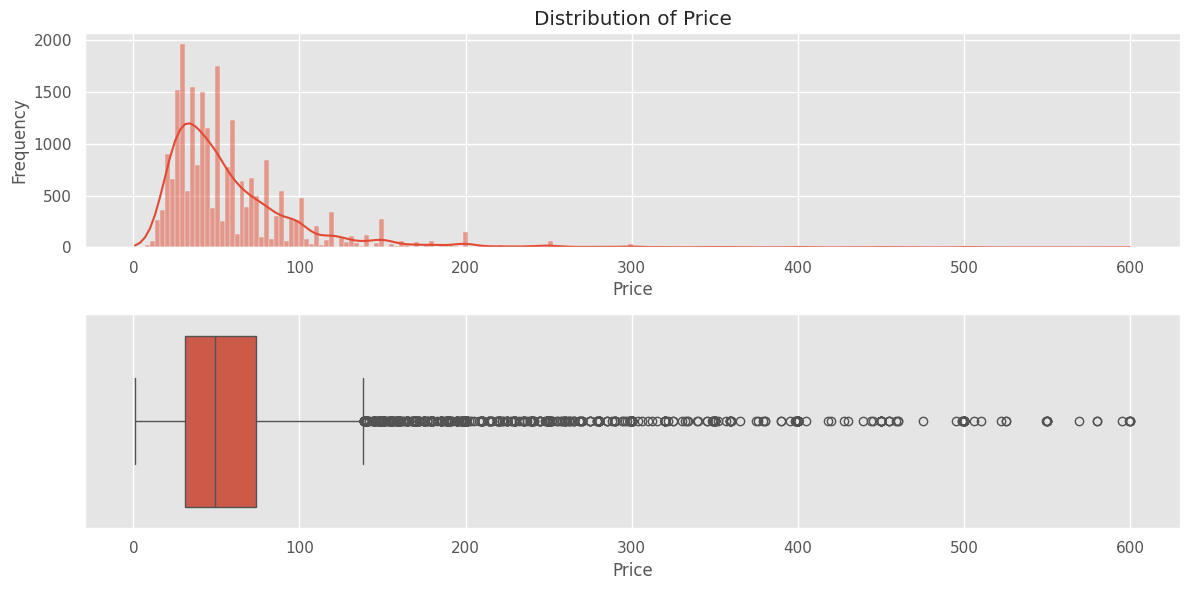

In [21]:
# Distribution of Price
target_value_distributions(df)

### Location vs Price

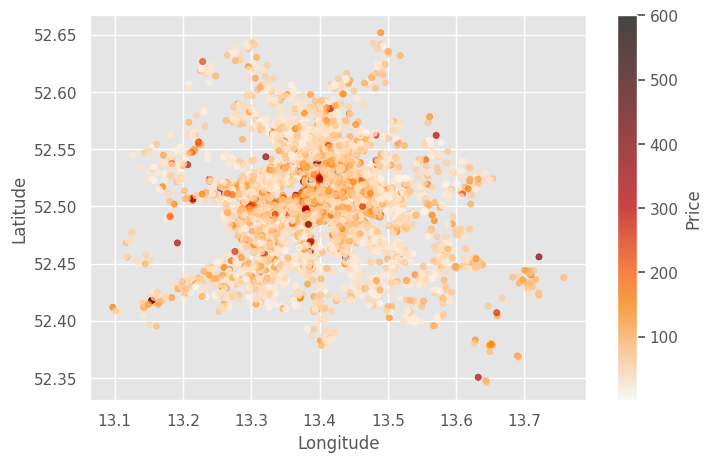

In [22]:
df.plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.7, figsize=(8,5),
        c="Price", cmap="gist_heat_r", colorbar=True, sharex=False);

In [23]:
df.columns

Index(['Accuracy Rating', 'Bathrooms', 'Checkin Rating', 'Cleanliness Rating',
       'Communication Rating', 'Host Response Rate', 'Latitude',
       'Location Rating', 'Longitude', 'Overall Rating', 'Price',
       'Square Feet', 'Value Rating', 'review_date', 'Comments', 'Host Since',
       'Host Response Time', 'Is Superhost', 'neighbourhood',
       'Neighborhood Group', 'Postal Code', 'Is Exact Location',
       'Property Type', 'Room Type', 'Instant Bookable', 'Accomodates',
       'Bedrooms', 'Beds', 'Guests Included', 'Min Nights', 'Reviews',
       'Property Type Reduced', 'Postal Code Reduced'],
      dtype='object')

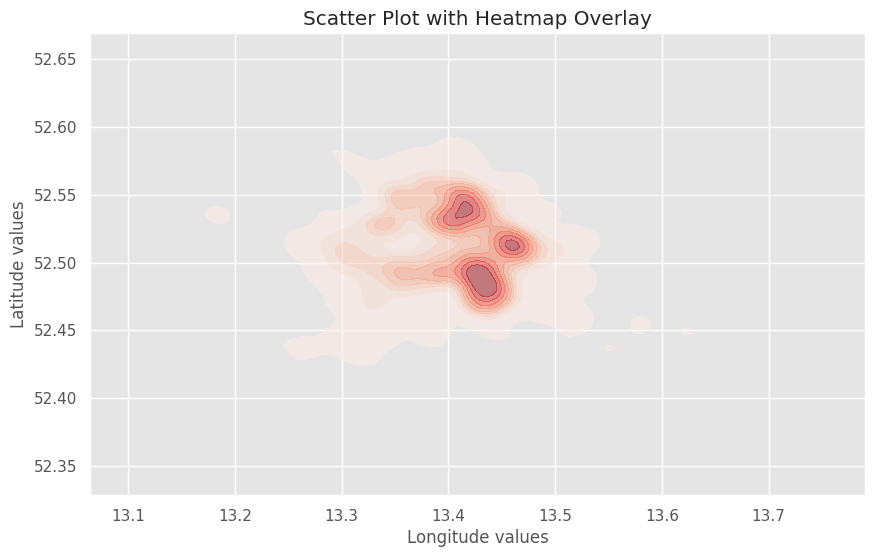

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot the heatmap using KDE (Kernel Density Estimation)
sns.kdeplot(x=df["Longitude"], y=df["Latitude"], cmap="Reds", fill=True, alpha=0.5)

# Overlay scatter plot
# sns.scatterplot(x=df["Longitude"], y=df["Latitude"], color="blue", alpha=0.5, cmap="viridis")
# sns.scatterplot(data=df, x="Longitude", y="Latitude", color="blue", alpha=0.5, cmap="viridis")
# sns.scatterplot(data=df, x="Longitude", y="Latitude", color="blue", alpha=0.5, size='Price' )

# Labels and title
plt.xlabel("Longitude values")
plt.ylabel("Latitude values")
plt.title("Scatter Plot with Heatmap Overlay")

# Show the plot
plt.show()


## Missing values

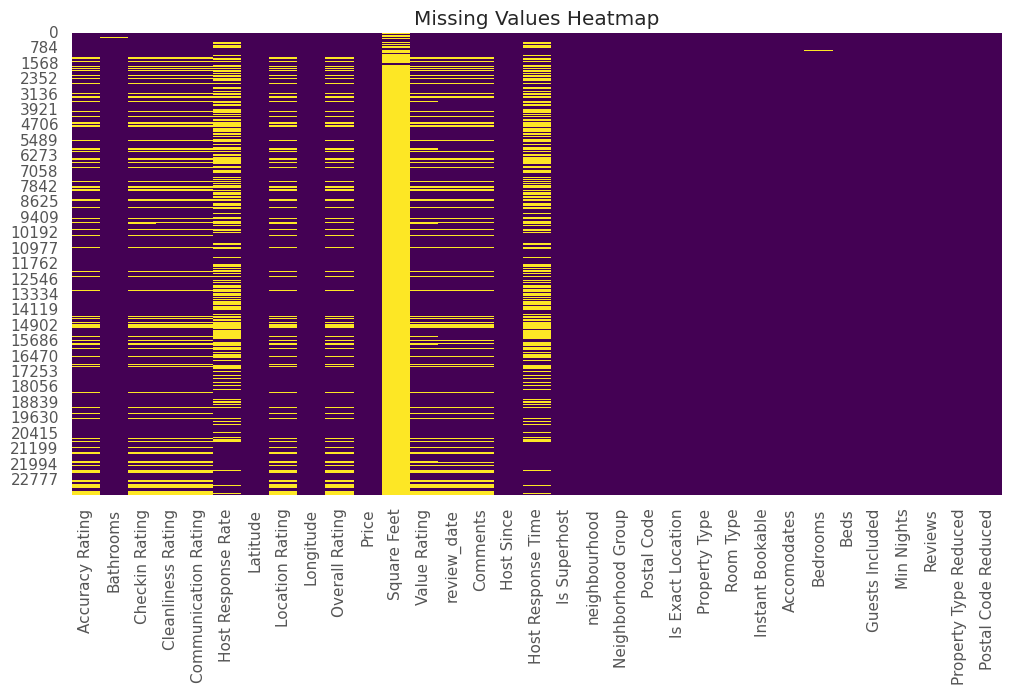

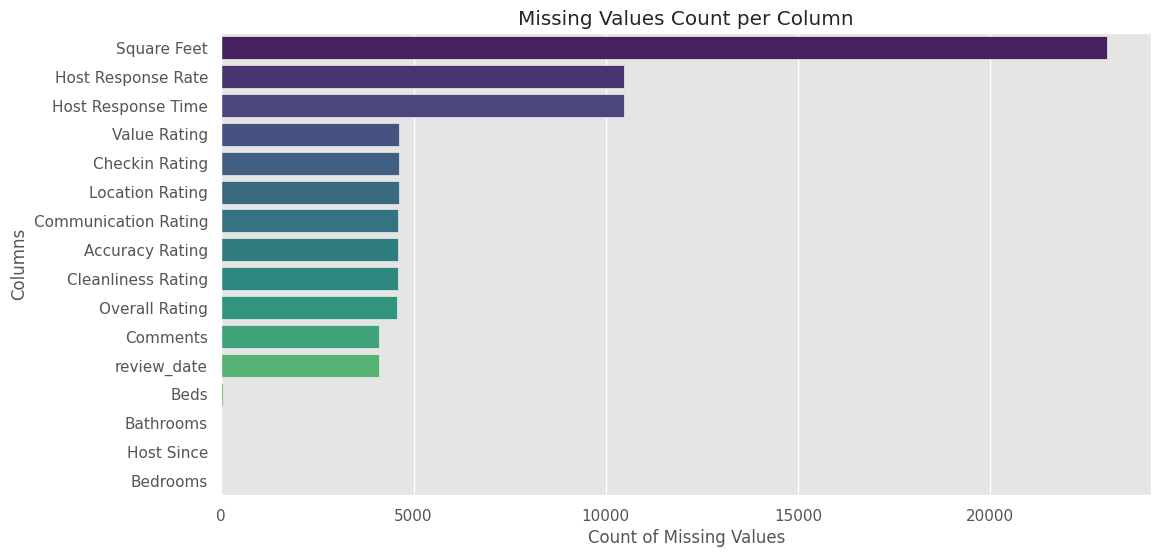


Missing Values:
Square Feet             23035
Host Response Rate      10476
Host Response Time      10476
Value Rating             4618
Checkin Rating           4616
Location Rating          4615
Communication Rating     4600
Accuracy Rating          4598
Cleanliness Rating       4594
Overall Rating           4572
Comments                 4110
review_date              4108
Beds                       34
Bathrooms                  29
Host Since                 20
Bedrooms                   20
dtype: int64


In [25]:
# Check for missing values
missing_values = df.isnull().sum()

# Visualizing missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# Display missing values as a bar chart
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_values.values, y=missing_values.index, palette="viridis")
plt.xlabel("Count of Missing Values")
plt.ylabel("Columns")
plt.title("Missing Values Count per Column")
plt.show()


print("\nMissing Values:")
print(missing_values)

## Dummies

In [26]:
def plot_counts_for_columns(df, columns_names, rows=1, cols=3, figsize_=(20, 6)):
  i = 1
  plt.figure(figsize=figsize_)
  plt.subplots_adjust(hspace = 0.5)
  for col in columns_names:
    plt.subplot(rows, cols, i)
    plt.title(f"'{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    sns.countplot(data=df, x=col, palette="viridis")
    i = i + 1

  plt.tight_layout()
  plt.show()
  print (i)

In [27]:
boolean_columns

['Is Superhost', 'Is Exact Location', 'Instant Bookable']

In [28]:
df['Is Superhost'] = df['Is Superhost'].astype(bool)
df[boolean_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 23460 entries, 0 to 23535
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Is Superhost       23460 non-null  bool 
 1   Is Exact Location  23460 non-null  bool 
 2   Instant Bookable   23460 non-null  bool 
dtypes: bool(3)
memory usage: 252.0 KB


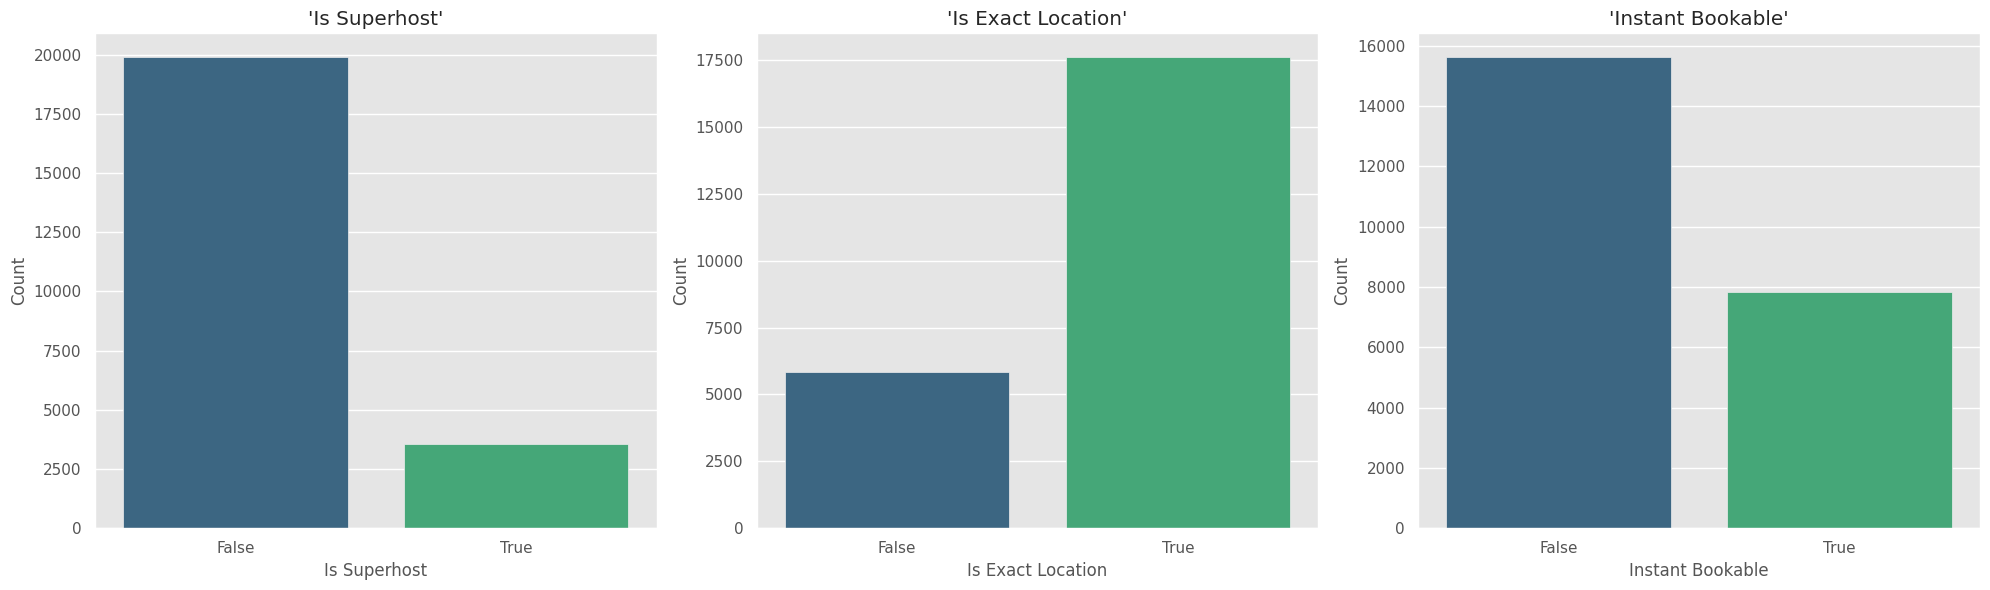

4


In [29]:
plot_counts_for_columns(df, boolean_columns)

## Categorial

In [30]:
df[categorical_columns].describe().T

,count,unique,top,freq
Room Type,23460,3,Private room,11658
Property Type Reduced,23460,15,Apartment,20914
Neighborhood Group,23460,12,Friedrichshain-Kreuzberg,5720
Postal Code Reduced,23460,8,10,14613
Host Response Time,12984,4,within an hour,6780


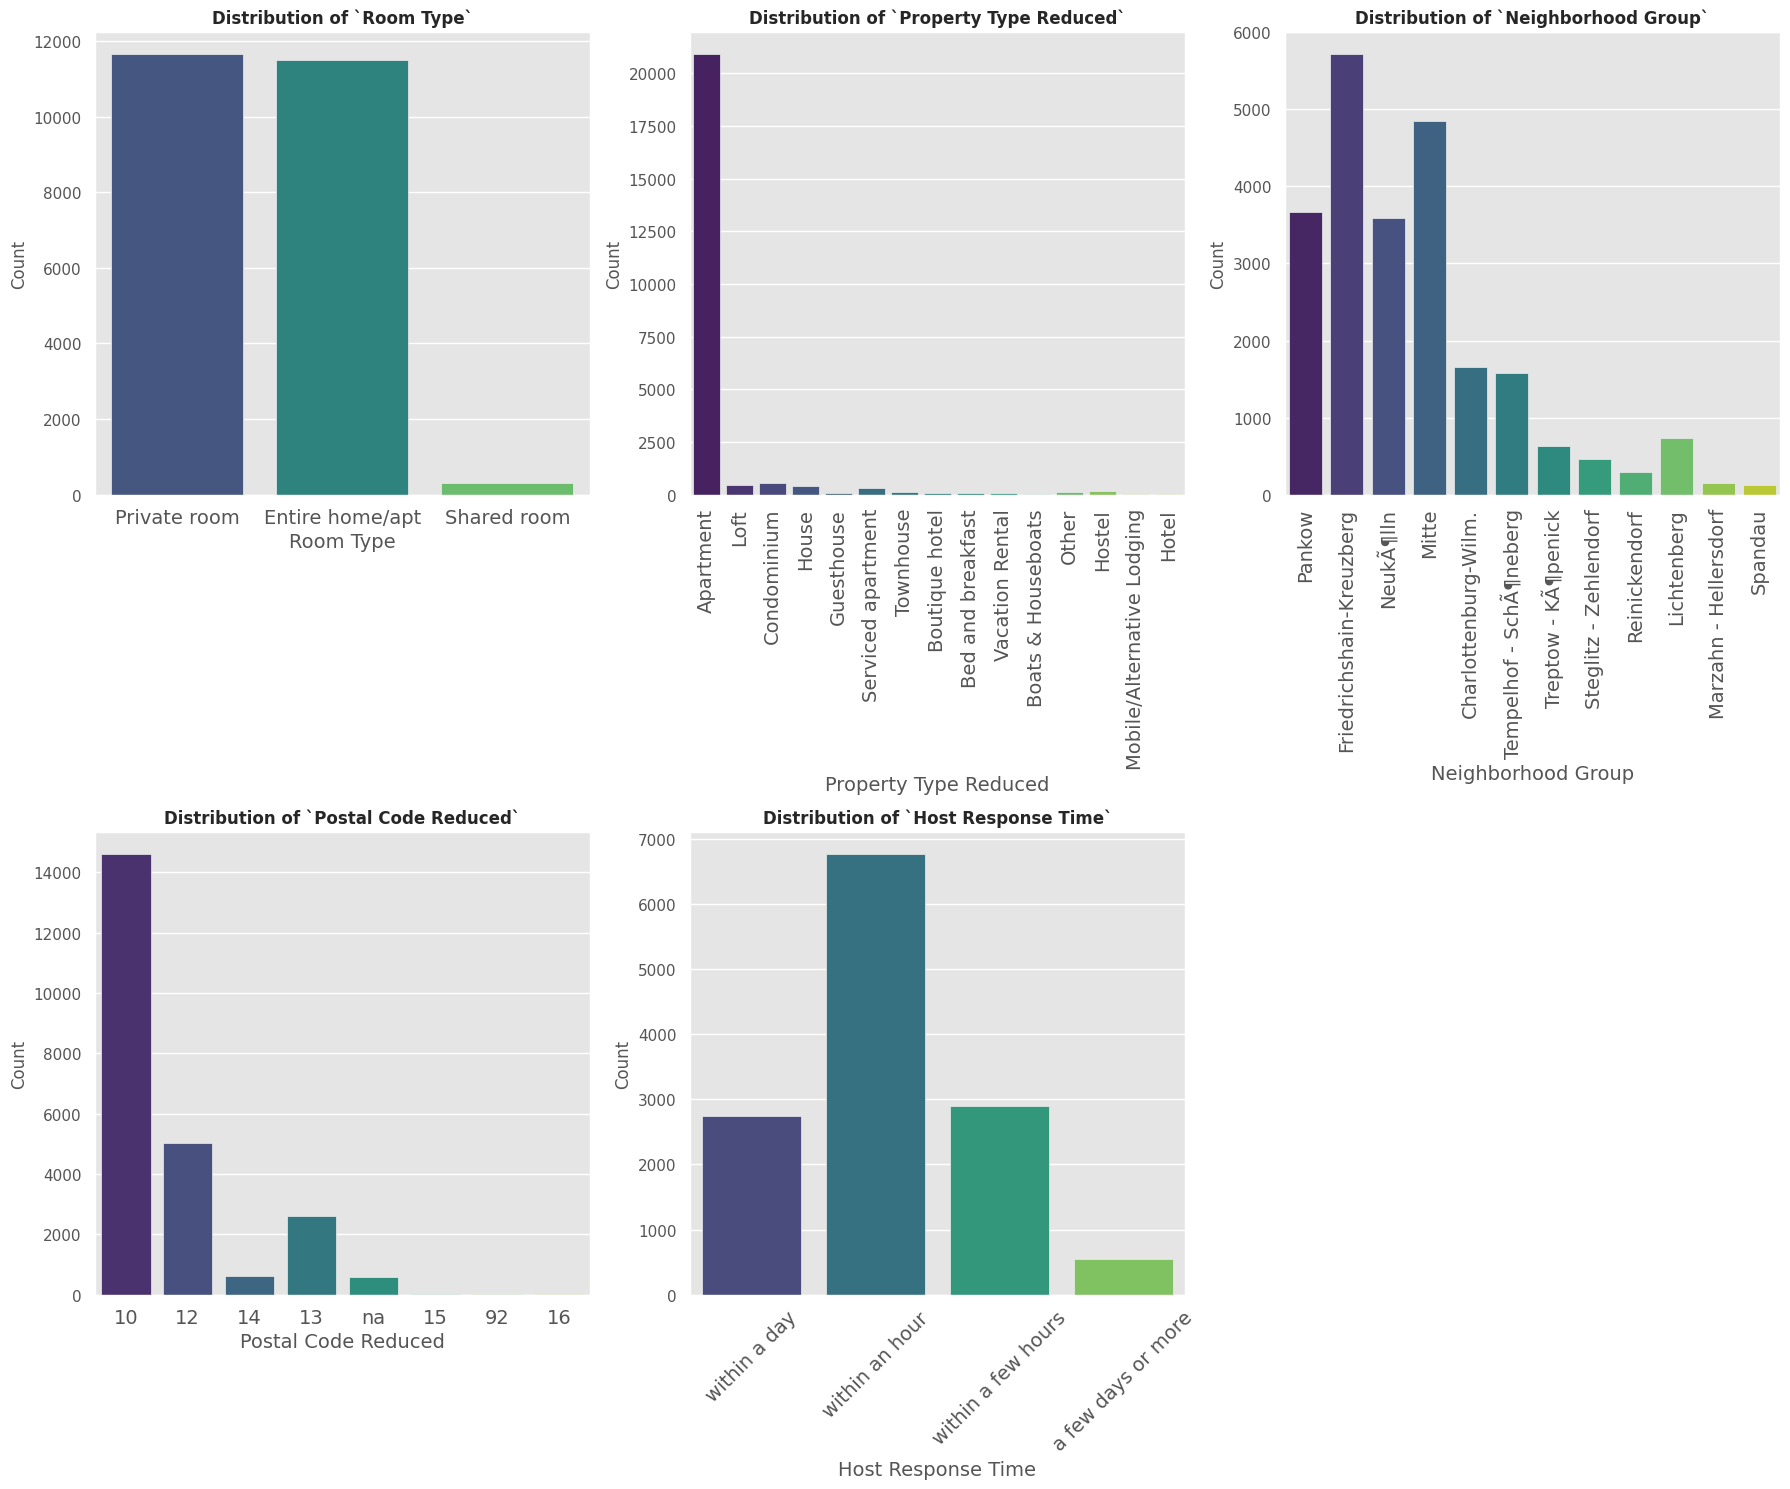

In [31]:
xticks_map = {'Room Type':0, 'Property Type Reduced':90, 'Neighborhood Group':90, 'Neighbourhood Grouped':90, 'Postal Code Reduced':0, 'Host Response Time':45}
i = 1
plt.figure(figsize=(18, 15))
plt.subplots_adjust(hspace = 0.5)
for col in categorical_columns:
  plt.subplot(2, 3, i)
  plt.title(f"Distribution of `{col}`", fontsize=12, fontweight="bold")
  plt.xlabel(col, fontsize=14)
  plt.xticks(rotation=xticks_map.get(col, 0), fontsize=14)
  plt.ylabel("Count")
  sns.countplot(data=df, x=col, palette="viridis")
  i = i + 1

plt.tight_layout()
plt.show()

In [32]:
# df = df_EDA.copy()

In [33]:
# df['Host Since Year'] = df['Host Since Year'].astype('str').apply(lambda x: (x.split('.')[0]))
# df['Host Since Year'] = df['Host Since Year'].apply(lambda x: None if x == 'nan' else x).astype('category')
# df['Host Since Month'] = df['Host Since Month'].astype('str').apply(lambda x: x.split('.')[0])
# df['Host Since Month'] = df['Host Since Month'].apply(lambda x: None if x == 'nan' else x).astype('category')
# df['Host Since Day'] = df['Host Since Day'].astype('str').apply(lambda x: x.split('.')[0])
# df['Host Since Day'] = df['Host Since Day'].apply(lambda x: None if x == 'nan' else x).astype('category')

In [34]:
# df['Host Since Year'].info()

In [35]:
# df['Host Since Year'].isna().sum()

In [36]:
# df['Host Since Month'].value_counts().index.sort_values()
# df['Host Since Month'].value_counts().index.sort_values( key=lambda x: pd.to_numeric(x, errors='coerce'))

In [37]:
# i = 1
# plt.figure(figsize=(15, 8))
# # Adjust spacing
# plt.subplots_adjust(hspace=0.6)
# for col in ['Host Since Year','Host Since Month','Host Since Day']:
#   plt.subplot(2, 2, i)
#   plt.title(f"Distribution of `{col}`", fontsize=10, fontweight="bold")
#   plt.xlabel(col)
#   plt.xticks(rotation=xticks_map.get(col, 0))
#   plt.ylabel("Count")
#   sorted_order = df[col].value_counts().index.sort_values( key=lambda x: pd.to_numeric(x, errors='coerce'))
#   sns.countplot(data=df, x=col, order=sorted_order, palette="viridis")
#   i = i + 1

# plt.tight_layout()
# plt.show()

## Continues and numrical data

### Histograms for continues numbers

Checking the distribution of key numerical features

In [38]:
numerical_columns

['Price',
 'Accomodates',
 'Bathrooms',
 'Bedrooms',
 'Beds',
 'Guests Included',
 'Min Nights',
 'Reviews']

In [39]:
def plot_histplot_for_columns(df, numerical_columns):
  plt.figure(figsize=(12, 12))
  plt.subplots_adjust(hspace = 0.5)
  for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[col].dropna(), bins=50, kde=False)
    plt.title(f"Distribution of {col}")

  plt.tight_layout()
  plt.show()

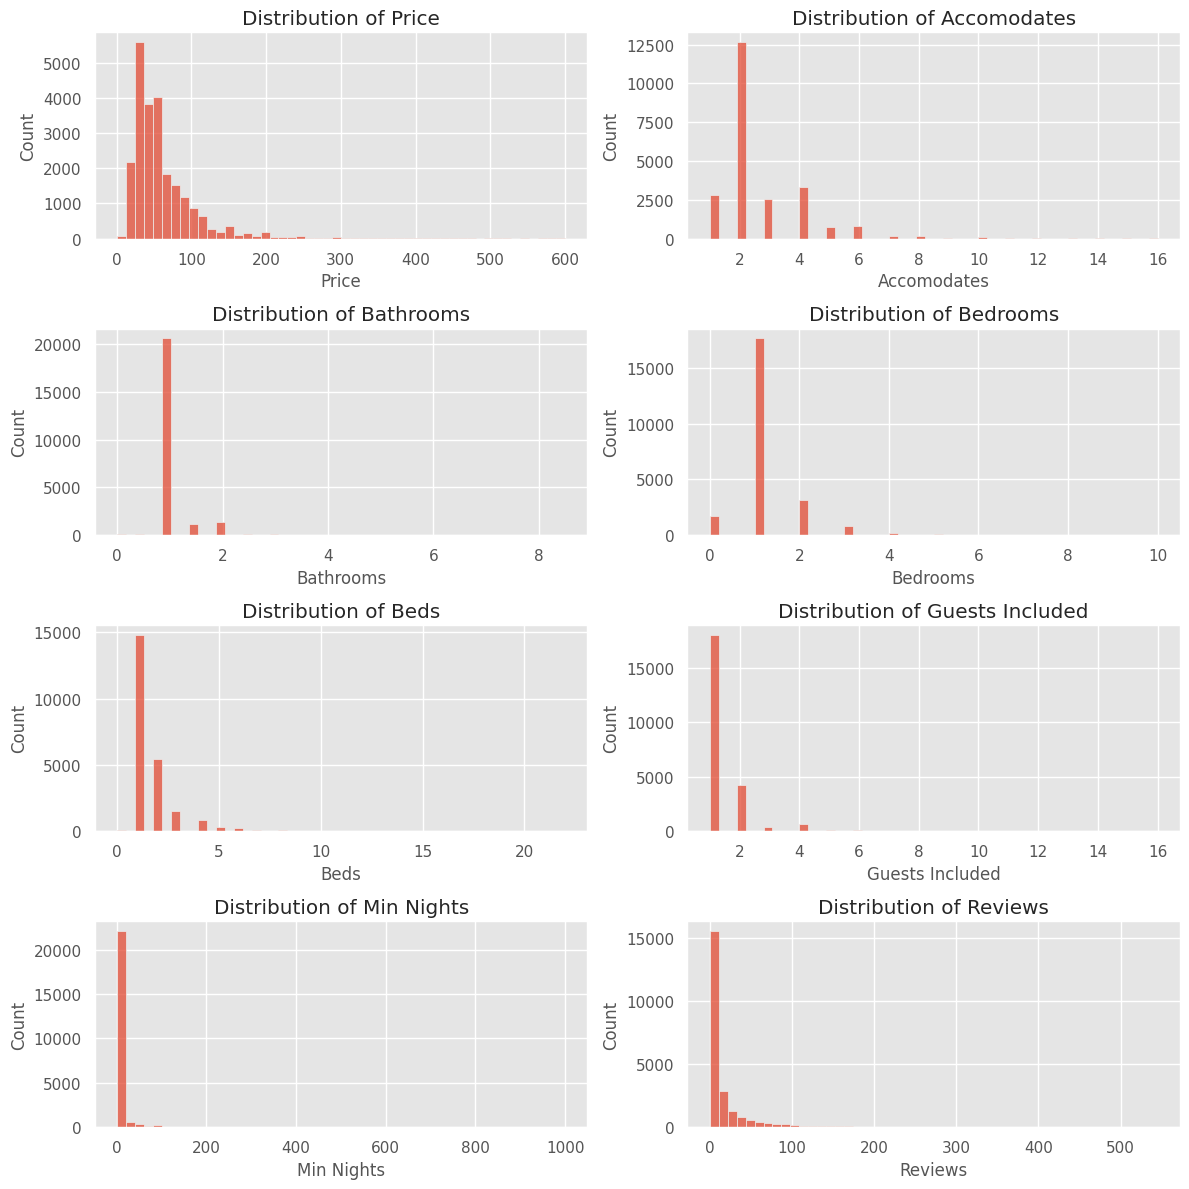

In [40]:
# Checking the distribution of key numerical features
plot_histplot_for_columns(df, numerical_columns)

As expected, we can notice that some of the numerics are more categorical data like (for example, Accomadates, Bathrooms and Beds).
It worth using barplot to show relations ship with target value

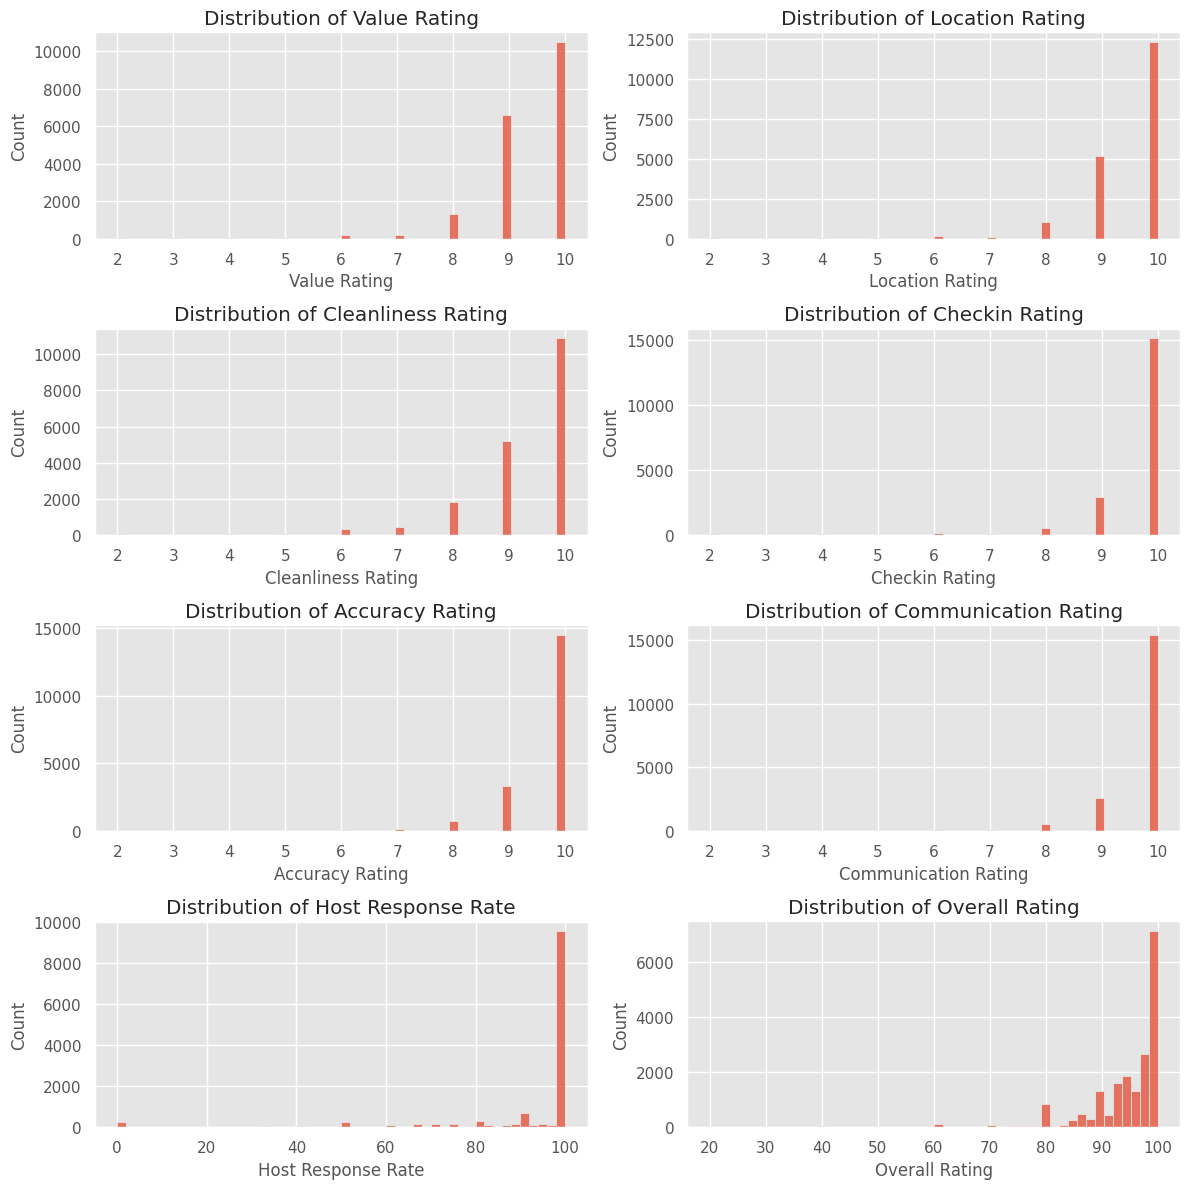

In [41]:
plot_histplot_for_columns(df, rating_columns)

### Bars for continues numbers

In [42]:
categorical_columns

['Room Type',
 'Property Type Reduced',
 'Neighborhood Group',
 'Postal Code Reduced',
 'Host Response Time']

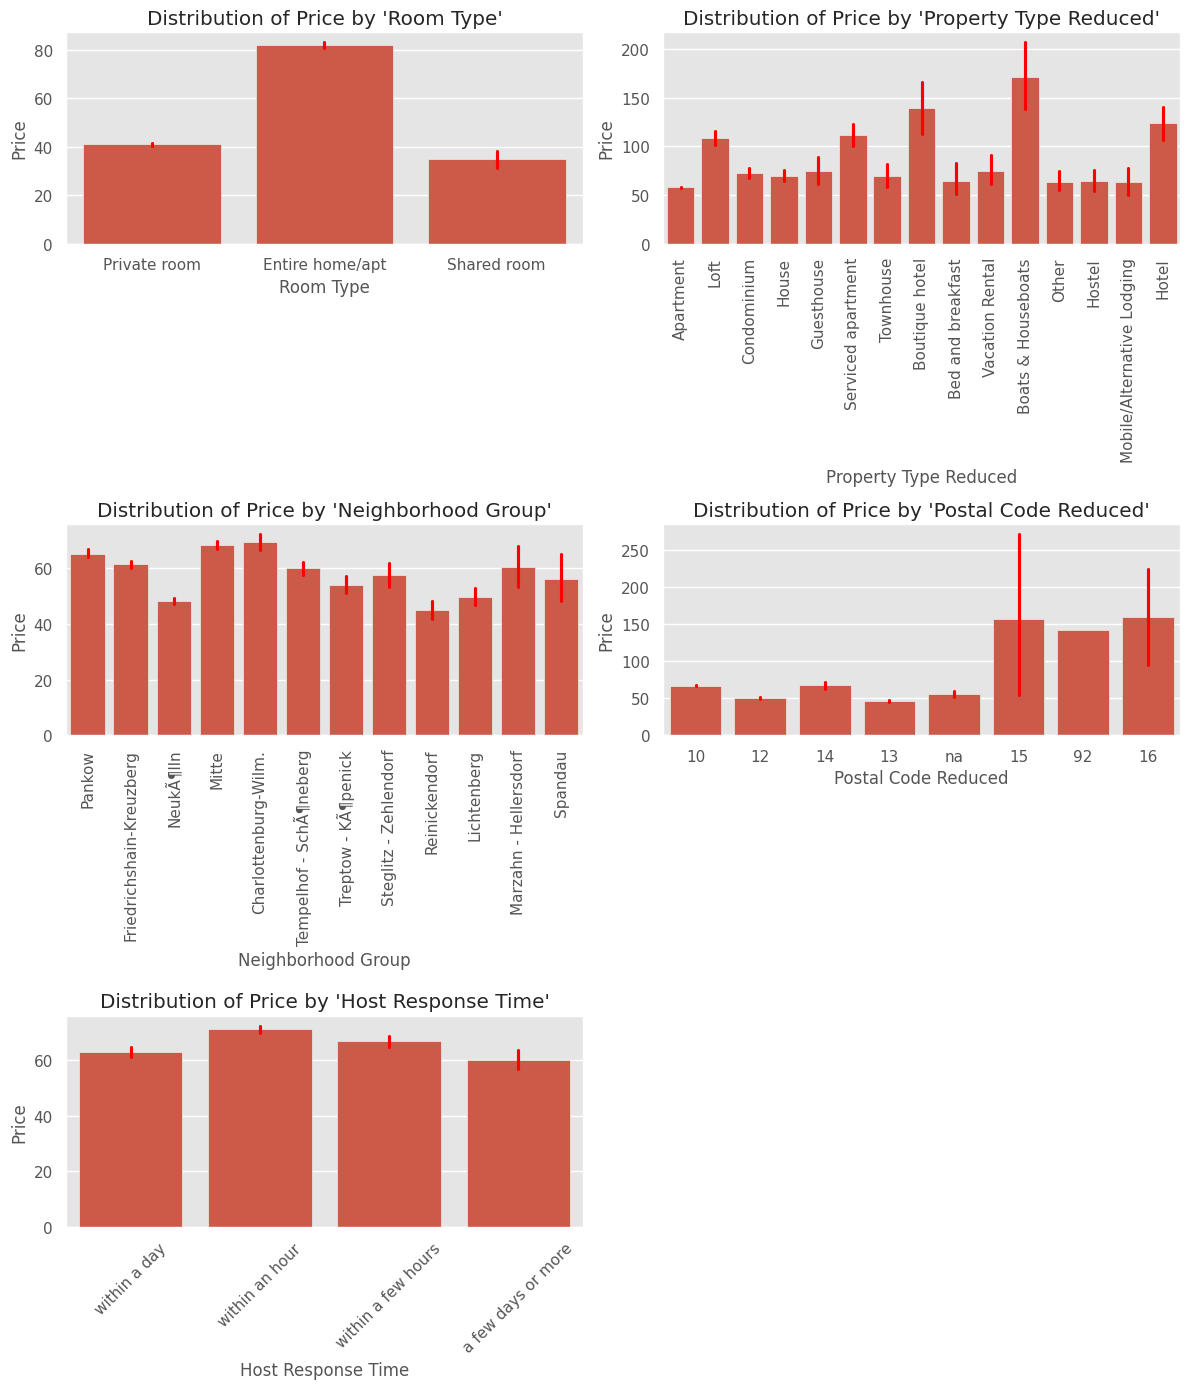

In [43]:
xticks_map = {'Room Type':0, 'Property Type Reduced':90, 'Neighborhood Group':90, 'Postal Code Reduced':0, 'Host Response Time':45}
plt.figure(figsize=(12, 14))
plt.subplots_adjust(hspace = 0.5)
for i, col in enumerate(categorical_columns, 1):
  plt.subplot(3, 2, i)
  sns.barplot(x=df[col], y=df['Price'], errcolor="red")
  plt.xticks(rotation=xticks_map.get(col))
  plt.title(f"Distribution of Price by '{col}'")

plt.tight_layout()
plt.show()

In [44]:
df['Room Type'].value_counts()

,count
Room Type,
Private room,11658
Entire home/apt,11491
Shared room,311


<Axes: xlabel='Price', ylabel='Count'>

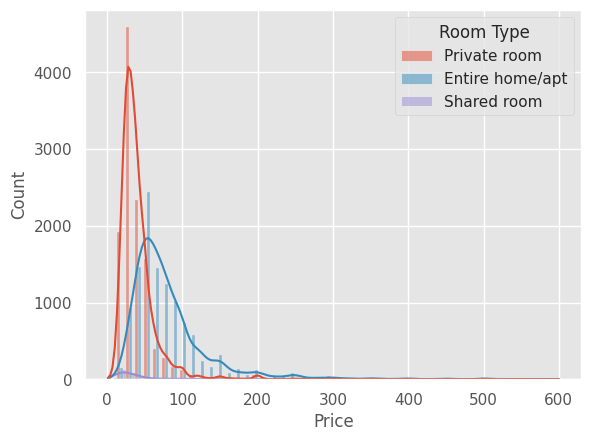

In [45]:
# sns.histplot(data = df[df['Room Type'] == 'Private room'], x="Price", bins=50, kde=True)
sns.histplot(data = df, x="Price", bins=50, hue="Room Type", kde=True, multiple="dodge")

In [46]:
boolean_columns

['Is Superhost', 'Is Exact Location', 'Instant Bookable']

<Axes: xlabel='Price', ylabel='Count'>

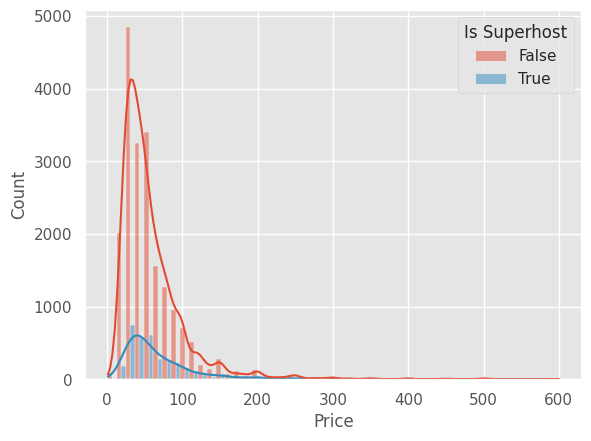

In [47]:
sns.histplot(data = df, x="Price", bins=50, hue="Is Superhost", kde=True, multiple="dodge")

<Axes: xlabel='Price', ylabel='Count'>

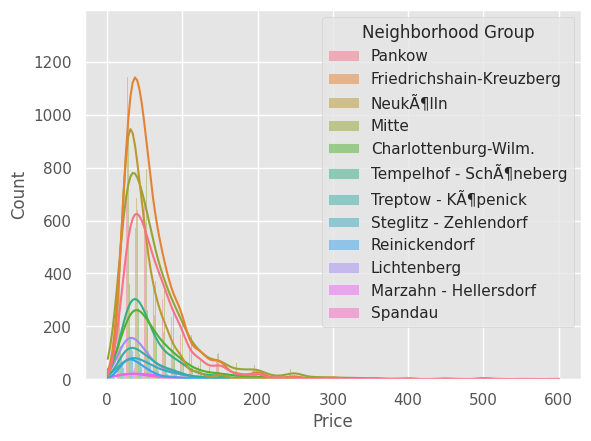

In [48]:
sns.histplot(data = df, x="Price", bins=50, hue="Neighborhood Group", kde=True, multiple="dodge")

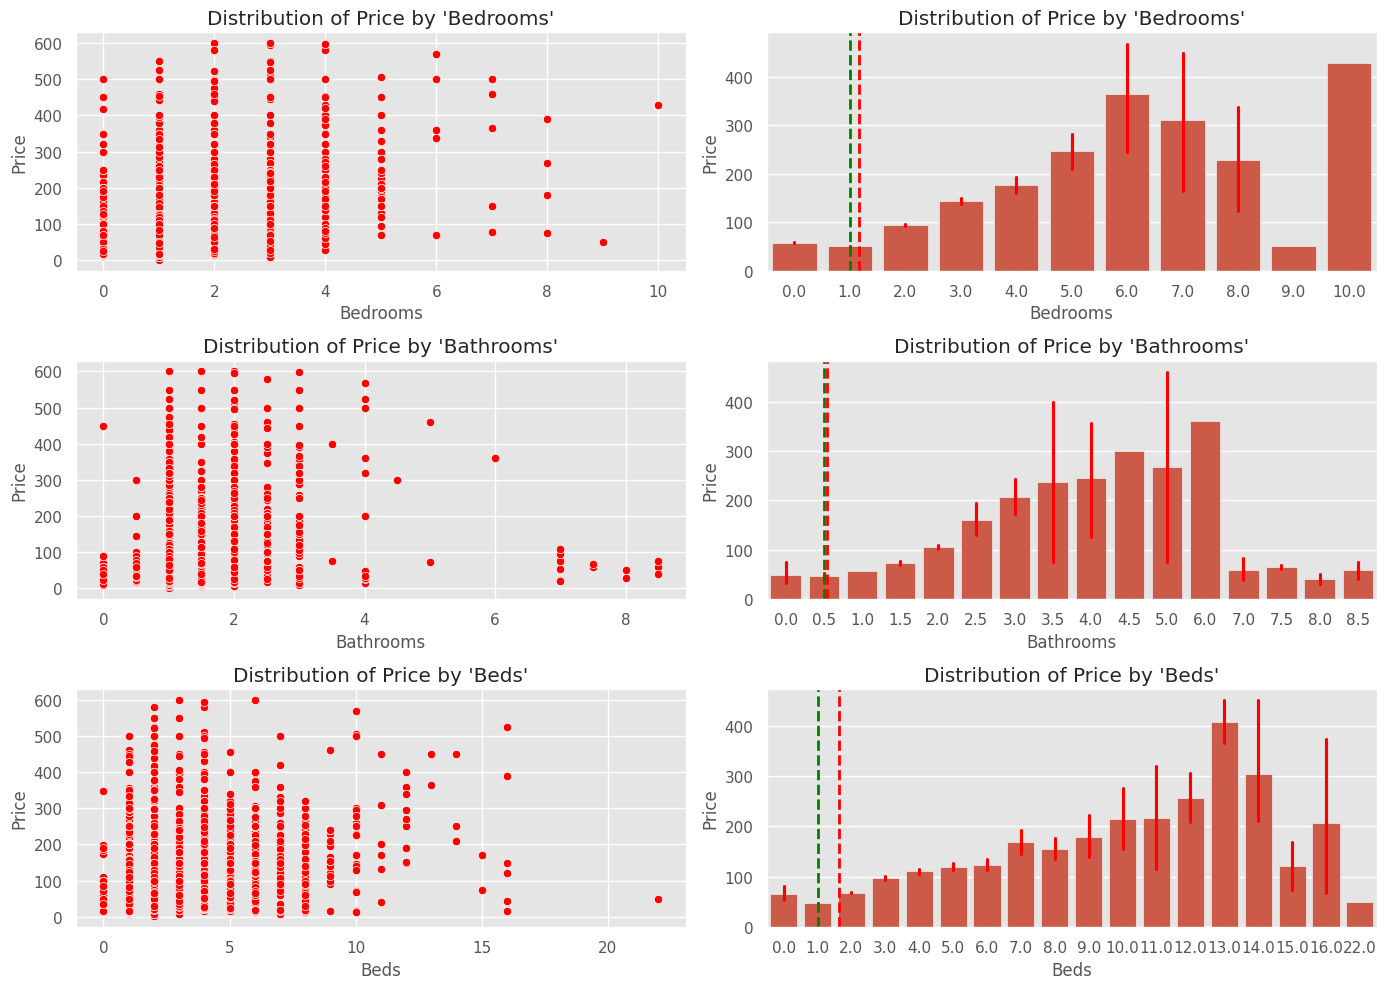

In [49]:
bar_plot_columns = ['Bedrooms', 'Bathrooms', 'Beds']
plt.figure(figsize=(14, 10))
plt.subplots_adjust(hspace = 0.5)
i = 1
for col in bar_plot_columns:
  plt.subplot(3, 2, i)
  sns.scatterplot(x=df[col], y=df['Price'], color='red')
  plt.title(f"Distribution of Price by '{col}'")

  plt.subplot(3, 2, i+1)
  sns.barplot(x=df[col], y=df['Price'], errcolor="red")
  plt.title(f"Distribution of Price by '{col}'")
  plt.axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=2)
  plt.axvline(df[col].median(), color='green', linestyle='dashed', linewidth=2)

  i = i + 2
plt.tight_layout()
plt.show()

## Skewness

In [50]:
def highlight(cell_value):
    highlight = 'background-color: mediumspringgreen;'
    default = ''
    negative = 'background-color: hotpink;'
    if cell_value > 1:
        return highlight
    elif cell_value < -1:
        return negative
    #else
       # return default

numericals = numerical_columns + rating_columns
pd.DataFrame(df[numericals].skew(),columns=['skewness']).sort_values(by='skewness', ascending=False).style.applymap(highlight)

,skewness
Min Nights,21.506775
Bathrooms,6.738902
Guests Included,5.068270
Reviews,4.345326
Price,3.714219
Beds,3.598453
Accomodates,2.563539
Bedrooms,2.113660
Cleanliness Rating,-2.470840
Location Rating,-2.602092


## Checking correlations among numerical features

In [51]:
from sklearn.preprocessing import LabelEncoder

correlation_matrix_df = df.copy()
correlation_matrix_df['Host Since'] = pd.to_datetime(correlation_matrix_df['Host Since'])
correlation_matrix_df['Host Since Year'] = correlation_matrix_df['Host Since'].dt.year

# correlation_matrix_df = correlation_matrix_df.drop(columns=['Listing ID'], inplace=False)
correlation_matrix_df = correlation_matrix_df.select_dtypes(include=['number'])

le = LabelEncoder()
for col in categorical_columns:
  correlation_matrix_df[col] = le.fit_transform(df[col])

correlation_matrix = correlation_matrix_df.corr(method = 'spearman')
correlation_matrix

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Latitude,Location Rating,Longitude,Overall Rating,Price,Square Feet,Value Rating,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Host Since Year,Room Type,Property Type Reduced,Neighborhood Group,Postal Code Reduced,Host Response Time
Accuracy Rating,1.000000,0.006310,0.421688,0.439086,0.452027,0.067496,-0.010288,0.277268,0.007996,0.504682,0.013267,-0.046632,0.466973,-0.068347,-0.015107,-0.094385,-0.019735,0.051160,0.020380,-0.014117,0.003075,-0.016254,0.023385,0.003656,-0.021792
Bathrooms,0.006310,1.000000,0.011782,0.006486,0.012124,0.025502,0.002502,0.019550,-0.038940,0.025882,0.134860,0.237171,0.006448,0.156795,0.246021,0.181533,0.090540,0.034927,0.003685,-0.015393,-0.007959,0.108463,-0.005159,-0.020376,-0.029129
Checkin Rating,0.421688,0.011782,1.000000,0.315407,0.530897,0.073366,-0.024226,0.233876,0.003390,0.383175,0.013840,0.003069,0.346310,-0.040509,0.000829,-0.045640,-0.008495,0.017417,0.006039,-0.006588,0.020630,0.016520,0.023201,0.021725,-0.022635
Cleanliness Rating,0.439086,0.006486,0.315407,1.000000,0.336250,0.104863,0.005036,0.217219,-0.012711,0.536756,0.109701,-0.002138,0.414862,-0.025764,0.024164,-0.029026,0.019746,0.012808,0.030925,-0.019725,-0.044139,0.048289,0.033427,-0.006598,-0.061873
Communication Rating,0.452027,0.012124,0.530897,0.336250,1.000000,0.103405,-0.019167,0.254591,0.005967,0.428698,0.024043,-0.048749,0.370536,-0.046071,0.000601,-0.062302,-0.008040,0.032425,0.005321,-0.029663,0.003264,-0.012157,0.021511,0.011635,-0.025161
Host Response Rate,0.067496,0.025502,0.073366,0.104863,0.103405,1.000000,0.002746,0.011694,-0.009776,0.060043,0.057301,-0.055334,0.047651,0.049720,0.035641,0.039136,0.063555,0.003731,0.126683,-0.021736,-0.012031,0.034354,0.014514,0.001600,0.481177
Latitude,-0.010288,0.002502,-0.024226,0.005036,-0.019167,0.002746,1.000000,0.002605,-0.150673,-0.035905,0.057407,-0.009606,-0.028445,0.040085,0.004600,0.028584,0.028408,-0.006008,0.039117,0.021866,-0.040273,0.007495,-0.024051,-0.115806,-0.017635
Location Rating,0.277268,0.019550,0.233876,0.217219,0.254591,0.011694,0.002605,1.000000,-0.009025,0.312819,0.107509,0.109152,0.316271,-0.051158,-0.020243,-0.071736,-0.034317,0.031919,-0.012515,-0.013121,-0.008191,-0.050379,-0.080322,-0.232805,-0.067337
Longitude,0.007996,-0.038940,0.003390,-0.012711,0.005967,-0.009776,-0.150673,-0.009025,1.000000,0.031048,-0.051213,-0.160150,0.027583,-0.018343,-0.010791,-0.036266,0.003868,-0.012872,-0.031048,-0.044229,0.035672,-0.015465,-0.022955,-0.076449,0.050897
Overall Rating,0.504682,0.025882,0.383175,0.536756,0.428698,0.060043,-0.035905,0.312819,0.031048,1.000000,0.019370,0.041631,0.561760,-0.089425,0.002468,-0.096480,-0.065424,0.083997,-0.272095,0.022734,0.017814,-0.017532,0.018470,0.008010,0.031741


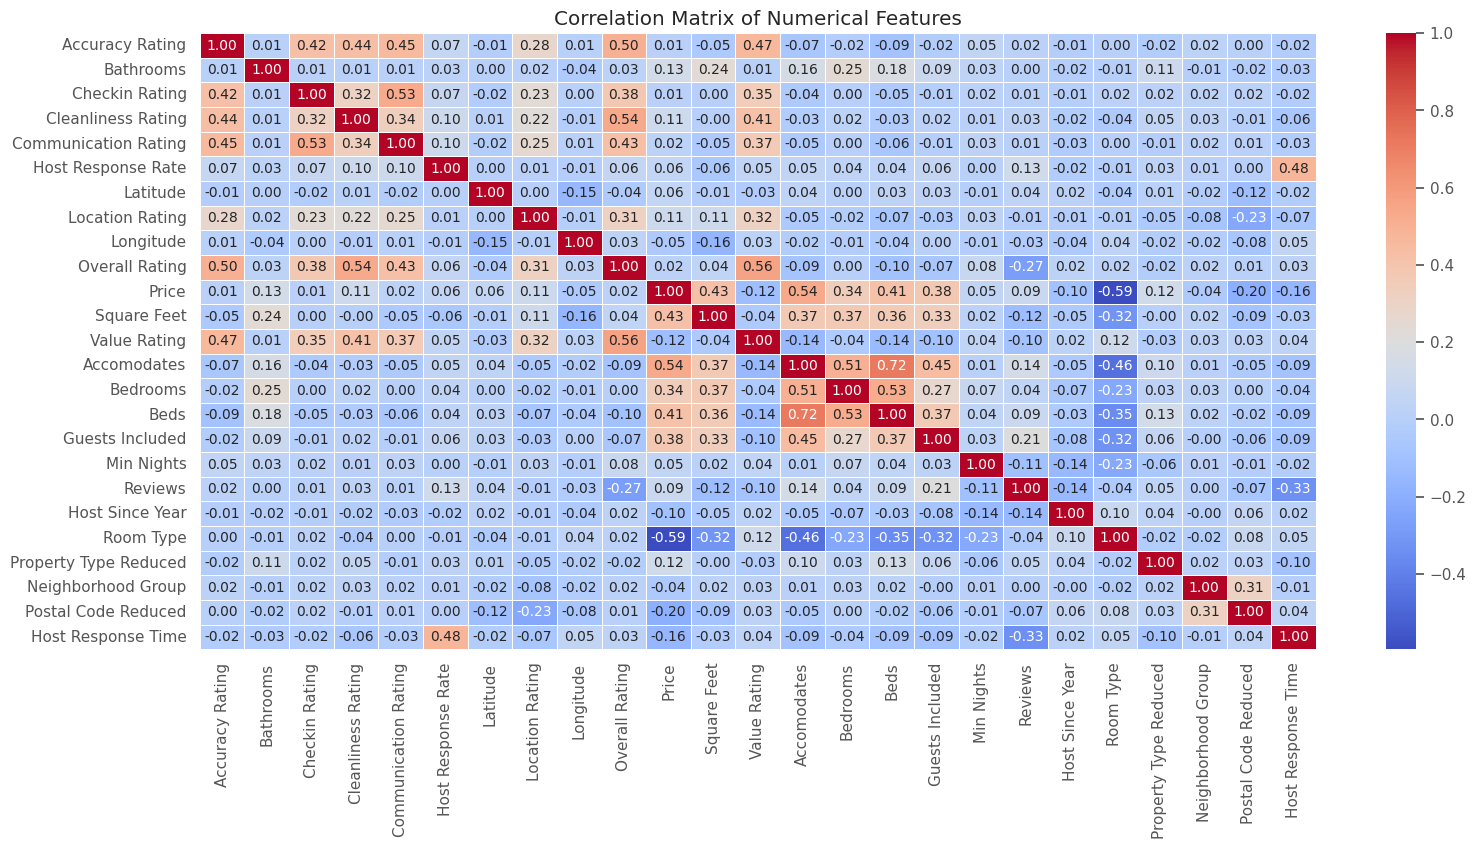

In [52]:
plt.figure(figsize=(18, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, annot_kws={"size": 10})
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## Outliers

In [53]:
nonn_dummy = numerical_columns + rating_columns
df[nonn_dummy].describe().loc[['min', '25%', '50%', '75%', 'max']].T

,min,25%,50%,75%,max
Price,1.0,31.0,49.0,74.0,600.0
Accomodates,1.0,2.0,2.0,3.0,16.0
Bathrooms,0.0,1.0,1.0,1.0,8.5
Bedrooms,0.0,1.0,1.0,1.0,10.0
Beds,0.0,1.0,1.0,2.0,22.0
Guests Included,1.0,1.0,1.0,1.0,16.0
Min Nights,1.0,2.0,3.0,4.0,1000.0
Reviews,0.0,1.0,5.0,17.0,545.0
Value Rating,2.0,9.0,10.0,10.0,10.0
Location Rating,2.0,9.0,10.0,10.0,10.0


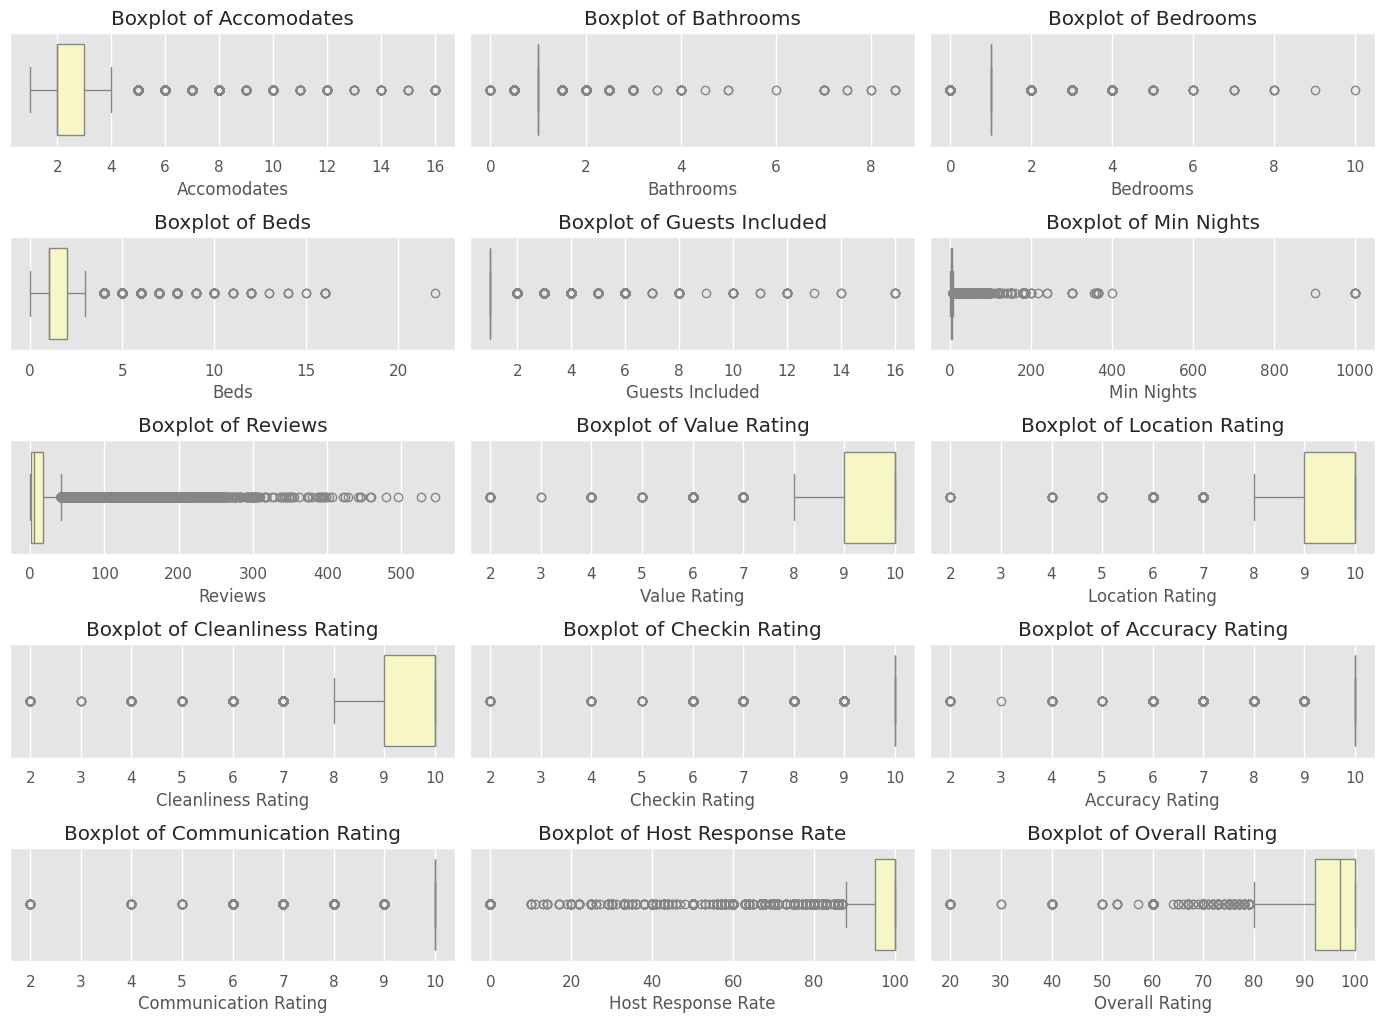

In [54]:
# numericals = numerical_columns + ["Overall Rating", "Host Response Rate"]

plt.figure(figsize=(14, 20))
for i, col in enumerate([c for c in nonn_dummy if c != 'Price'], 1):
    plt.subplot(10, 3, i)
    sns.boxplot(x=df[col].dropna(), palette="Spectral")
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

The boxplots reveal potential outliers in several numerical features, particularly:

1. Price: Likely contains extreme values (high-end listings or pricing errors).
2. Reviews: Some listings have significantly higher review counts than others.
3. Bedrooms, Bathrooms, Beds, Accommodates: Some properties might have unrealistic values (e.g., too many or too few bedrooms relative to accommodations).

## Save state

In [55]:
df.to_pickle("/content/drive/My Drive/Airbnb/df_EDA2.pkl")
df.to_csv("/content/drive/My Drive/Airbnb/df_EDA2.csv")

In [56]:
# cleaned_df = pd.read_pickle('/content/drive/My Drive/Airbnb/df_EDA2.pkl')
# cleaned_df.info()